#Instructions:

Fill out the information labeled "USER INPUT". If you don't fill out this information, the code won't run correctly.

At the end of the code you should see a a proper test set performance and ROC curve. You will also see a map displaying the results of the prediction model.

There are two code blocks for generating the map: federal and state. Make sure you use the right one depending on your labels.

In [ ]:
import pandas as pd
import glob
import os
import datetime

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

#------USER INPUT--------#
#input the folder path where your GEE .csv files are stored
folder_path = '/content/drive/MyDrive/Research/Young/MOSAIKS/superfund_project_summer2026/Data/Intermediate/'
file_pattern = os.path.join(folder_path, 'GEE_featurization_MN_2026-07-16_*.csv') #name pattern of files from GEE
file_list = glob.glob(file_pattern)

print(f"Found {len(file_list)} files to combine.")

# 3. Read each file into a list of DataFrames
df_list = [pd.read_csv(f) for f in file_list]

# 4. Concatenate (stack) them into one master DataFrame
full_df = pd.concat(df_list, ignore_index=True)

# 5. Check the final count to make sure it matches your # of points
print(f"Final combined row count: {len(full_df)}")
full_df.head()

gdf_test=full_df

Mounted at /content/drive
Found 34 files to combine.
Final combined row count: 16932


In [ ]:
#additional packages required for the next step

import gc
import shutil
import zipfile
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import urllib.request
import geopandas as gpd
import matplotlib.pyplot as plt


from google.colab import drive

from scipy.linalg import LinAlgWarning
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings(
    "ignore", category=LinAlgWarning, module="sklearn.linear_model._ridge"
)

drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
#------USER INPUT--------#
#exclude columns that aren't used in the test
#In the next code, if additional columns exist in your .csv files that shouldn't be there, you can eliminate them here
feature_cols = [col for col in gdf_test.columns if col not in [
    "A00_mean", "A63_mean", "A62_mean", "A61_mean", "A60_mean", "A59_mean",
    "A58_mean", "A57_mean", "A56_mean", "A55_mean", "A54_mean", "A53_mean", "A52_mean",
    "A51_mean", "A50_mean", "A49_mean", "A48_mean", "A47_mean", "A46_mean", "A45_mean",
    "A44_mean", "A43_mean", "A42_mean", "A41_mean", "A40_mean", "A39_mean", "A38_mean",
    "A37_mean", "A36_mean", "A35_mean", "A34_mean", "A33_mean", "A32_mean", "A31_mean",
    "A30_mean", "A29_mean", "A28_mean", "A27_mean", "A26_mean", "A25_mean", "A24_mean",
    "A23_mean", "A22_mean", "A21_mean", "A20_mean", "A19_mean", "A18_mean", "A17_mean",
    "A16_mean", "A15_mean", "A14_mean", "A13_mean", "A12_mean", "A11_mean", "A10_mean",
    "A09_mean", "A08_mean", "A07_mean", "A06_mean", "A05_mean", "A04_mean", "A03_mean",
    "A02_mean", "A01_mean",
    "Unnamed: 0", "system:index", "indicator", "lat", "lon", "Number", "number", ".geo"
    ]
                ]

y_var = "indicator"

X = gdf_test[feature_cols]
y = gdf_test[y_var]
c = gdf_test[["lon", "lat"]]

In [ ]:
#------USER INPUT--------#
#THIS IS A CHECKPOINT
#REVIEW RESULTS OF THIS CODE BLOCK TO ENSURE ONLY AXX_ NON-MEAN NAMES ARE IN THE COLUMN
print(feature_cols)

#IF ADDITIONAL NAMES ARE IN THE FOLLOWING LIST, ADD THEM TO THE PREVIOUS CODE BLOCK TO ELIMINATE THEM FROM CONSIDERATION IN THE TESTING PROCESS
#IF ONLY AXX_ NON-MEAN NAMES ARE IN THE COLUMN, PROCEED TO NEXT STEP


['A00_p0', 'A00_p10', 'A00_p100', 'A00_p20', 'A00_p30', 'A00_p40', 'A00_p50', 'A00_p60', 'A00_p70', 'A00_p80', 'A00_p90', 'A01_p0', 'A01_p10', 'A01_p100', 'A01_p20', 'A01_p30', 'A01_p40', 'A01_p50', 'A01_p60', 'A01_p70', 'A01_p80', 'A01_p90', 'A02_p0', 'A02_p10', 'A02_p100', 'A02_p20', 'A02_p30', 'A02_p40', 'A02_p50', 'A02_p60', 'A02_p70', 'A02_p80', 'A02_p90', 'A03_p0', 'A03_p10', 'A03_p100', 'A03_p20', 'A03_p30', 'A03_p40', 'A03_p50', 'A03_p60', 'A03_p70', 'A03_p80', 'A03_p90', 'A04_p0', 'A04_p10', 'A04_p100', 'A04_p20', 'A04_p30', 'A04_p40', 'A04_p50', 'A04_p60', 'A04_p70', 'A04_p80', 'A04_p90', 'A05_p0', 'A05_p10', 'A05_p100', 'A05_p20', 'A05_p30', 'A05_p40', 'A05_p50', 'A05_p60', 'A05_p70', 'A05_p80', 'A05_p90', 'A06_p0', 'A06_p10', 'A06_p100', 'A06_p20', 'A06_p30', 'A06_p40', 'A06_p50', 'A06_p60', 'A06_p70', 'A06_p80', 'A06_p90', 'A07_p0', 'A07_p10', 'A07_p100', 'A07_p20', 'A07_p30', 'A07_p40', 'A07_p50', 'A07_p60', 'A07_p70', 'A07_p80', 'A07_p90', 'A08_p0', 'A08_p10', 'A08_p100'

In [ ]:
X_train, X_test, y_train, y_test, c_train, c_test = train_test_split(
    X, y, c, test_size=0.2, random_state=42
)

--- Test Set Performance ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      2842
           1       0.86      0.77      0.81       545

    accuracy                           0.94      3387
   macro avg       0.91      0.87      0.89      3387
weighted avg       0.94      0.94      0.94      3387

ROC-AUC:     0.9455
Accuracy:    0.9424
Precision:   0.8601
Log Loss:    0.1775


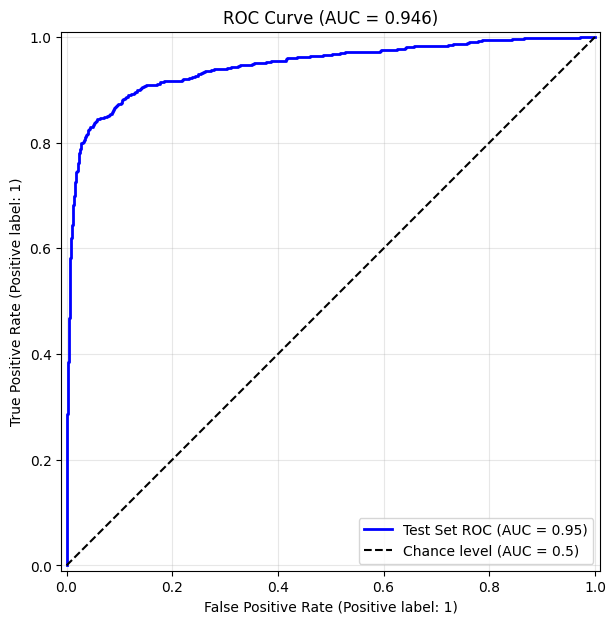

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the classifier
clf = LogisticRegression(max_iter=5000, C=1.0, random_state=123)

from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    log_loss, RocCurveDisplay, classification_report
)
import matplotlib.pyplot as plt

# 1. Fit the model on training data
clf.fit(X_train, y_train.values.ravel())

# 2. Generate Predictions on the Test Set
# Probabilities are needed for ROC and Log Loss
y_probs = clf.predict_proba(X_test)[:, 1]
# Classes are needed for Accuracy and Precision
y_pred = clf.predict(X_test)

# 3. Calculate the "Big Four" Metrics
auc_val = roc_auc_score(y_test, y_probs)
acc_val = accuracy_score(y_test, y_pred)
prec_val = precision_score(y_test, y_pred)
loss_val = log_loss(y_test, y_probs)

# 4. Print the Performance Dashboard
print("--- Test Set Performance ---")
print(classification_report(y_test, y_pred))
print(f"{'ROC-AUC:':<12} {auc_val:.4f}")
print(f"{'Accuracy:':<12} {acc_val:.4f}")
print(f"{'Precision:':<12} {prec_val:.4f}")
print(f"{'Log Loss:':<12} {loss_val:.4f}")

# 5. Generate the ROC Curve Plot
fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(
    y_test,
    y_probs,
    name="Test Set ROC",
    color="blue",
    lw=2,
    ax=ax,
    plot_chance_level=True
)

ax.set_title(f"ROC Curve (AUC = {auc_val:.3f})")
plt.grid(alpha=0.3)

#------USER INPUT--------#
#Save image to your Drive folder: edit the output folder path and file name as needed
today_date = datetime.date.today().strftime("%Y-%m-%d")
output_folder = '/content/drive/MyDrive/MOSAIKS/superfund_project_summer2026/Results/Figures/Testing Phase' #output folder path
output_plot_filename = f'{today_date}_ROC_curve_.01_Federallabels_firsttest_no_train_test_split.pdf' #rename as needed
full_plot_path = os.path.join(output_folder, output_plot_filename)
plt.savefig(full_plot_path, dpi=300, bbox_inches='tight')

#Save text results to Drive folder
output_text_filename = f'{today_date}_performance_results_.01_Federallabels_firsttest_no_train_test_split.txt' #rename as needed
full_text_path = os.path.join(output_folder, output_text_filename)
with open(full_text_path, 'w') as f:
    f.write("--- Test Set Performance ---")
    f.write(classification_report(y_test, y_pred))
    f.write(f"{'ROC-AUC:':<12} {auc_val:.4f}\n")
    f.write(f"{'Accuracy:':<12} {acc_val:.4f}\n")
    f.write(f"{'Precision:':<12} {prec_val:.4f}\n")
    f.write(f"{'Log Loss:':<12} {loss_val:.4f}\n")


plt.show()

#Maps

/tmp/ipykernel_756/1052731420.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_binary = plt.cm.get_cmap("viridis", 2) ## Get 2 discrete colors from viridis


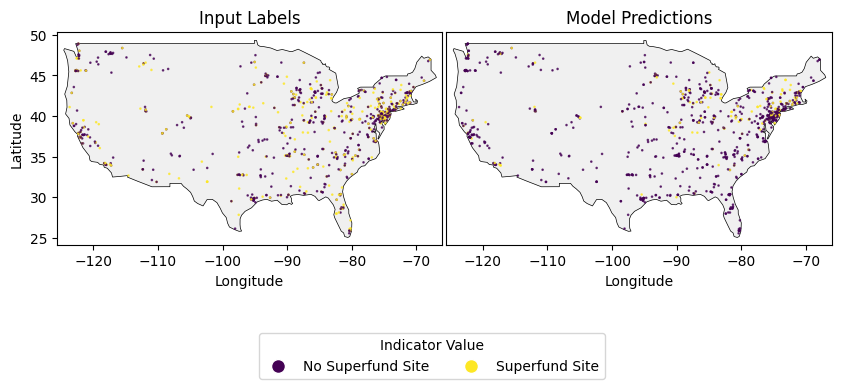

In [ ]:
#PLOT ON US MAP
#------USER INPUT--------#
#THIS BLOCK OF CODE IS FOR US MAP ONLY. SEE BLOCKS BELOW FOR STATE-SPECIFIC MAPS.
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
import warnings


# --- 1. LOAD THE US BORDER SHAPEFILE ---
usa_adm0_fp = "https://gist.githubusercontent.com/krithin/7d694393e8a0b69dd3bd30336ecd46ad/raw/6a0d564a2dd5da4bfa5f035af25a36f6d35ccdf4/us_lower_48.geo.json"
usa_gdf = gpd.read_file(usa_adm0_fp)

# --- 2. CONSTRUCT GDF_TEST FROM TEST DATA ---
# Combine c_test (coordinates), y_test (actual labels), and y_pred (predictions) into a single DataFrame
# y_test is a Series, so convert it to DataFrame and reset index to join with c_test
# y_pred is a numpy array, convert it to Series or DataFrame
# This is different from Maddy's code - GEE's production of gdf_test is not a GeoDataFrame.
# We need to convert gdf_test to a GeoDataFrame because accessing its CRS.

if 'c_test' in locals() and 'y_test' in locals() and 'y_pred' in locals():
    # Reset index of y_test to align with c_test if they don't share the same index after train_test_split
    temp_df = c_test.reset_index(drop=True)
    temp_df['actual_label'] = y_test.reset_index(drop=True)
    temp_df['prediction'] = y_pred

    # Convert to GeoDataFrame
    gdf_test = gpd.GeoDataFrame(
        temp_df,
        geometry=gpd.points_from_xy(temp_df['lon'], temp_df['lat']),
        crs="EPSG:4326"
    )
else:
    print("Error: 'c_test', 'y_test', or 'y_pred' are not defined.")
    gdf_test = None # Set gdf_test to None to prevent further errors

# Confirm both maps use the same CRS
if gdf_test is not None:
    if usa_gdf.crs != gdf_test.crs:
        print("Aligning CRS of US border map...")
        usa_gdf = usa_gdf.to_crs(gdf_test.crs)

    # --- 3. SET UP THE PLOT ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.subplots_adjust(wspace=0.01)

    # --- 4. PREPARE YOUR BINARY COLORMAP ---
    # Assumes actual_label and prediction are binary (0 or 1)
    cmap_binary = plt.cm.get_cmap("viridis", 2) ## Get 2 discrete colors from viridis
    #this line is giving me a warning saying the command is getting discontinued, but I can't get its suggestions to work?

    # When plotting points with 'column' and a discrete cmap, ensure vmin/vmax are set for consistency
    vmin, vmax = 0, 1 # Assuming binary values are 0 and 1

    # --- 5. PLOT THE FIRST MAP
    usa_gdf.plot(
        ax=axes[0],
        color='#f0f0f0',
        edgecolor='black',
        linewidth=0.5
    )
    # Plot your points on top
    plot1 = gdf_test.plot(
        column="actual_label",
        ax=axes[0],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap_binary,
        legend=False,
        markersize=0.75,
        alpha=0.75,
    )
    axes[0].set_title("Input Labels")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # --- 6. PLOT THE SECOND MAP (Model Predictions) ---
    usa_gdf.plot(
        ax=axes[1],
        color='#f0f0f0',
        edgecolor='black',
        linewidth=0.5
    )
    plot2 = gdf_test.plot(
        column="prediction",
        ax=axes[1],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap_binary,
        legend=False,
        markersize=0.75,
        alpha=0.75,
    )
    axes[1].set_title("Model Predictions")
    axes[1].set_xlabel("Longitude")
    axes[1].yaxis.set_visible(False)

    # --- 7. SET THE MAP BOUNDARIES ---
    minx, miny, maxx, maxy = usa_gdf.total_bounds
    axes[0].set_xlim(minx - 1, maxx + 1)
    axes[0].set_ylim(miny - 1, maxy + 1)
    axes[1].set_xlim(minx - 1, maxx + 1)
    axes[1].set_ylim(miny - 1, maxy + 1)

    # --- 8. ADD A BINARY LEGEND ---
    # Define custom handles for the binary legend
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', label='No Superfund Site',
                   markerfacecolor=cmap_binary(0), markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Superfund Site',
                   markerfacecolor=cmap_binary(1), markersize=10)
    ]

    # Add the legend to the figure
    # Adjust bbox_to_anchor and loc to place the legend appropriately outside the subplots
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, 0.0),
               title="Indicator Value")

    plt.show()

#save plot to drive
output_plot_filename = f'{today_date}_Map_.01_Federallabels_firsttest_no_train_test_split.pdf' #rename as needed
full_plot_path = os.path.join(output_folder, output_plot_filename)
plt.savefig(full_plot_path, dpi=300, bbox_inches='tight')

/tmp/ipykernel_2757/3893580764.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_binary = plt.cm.get_cmap("viridis", 2) ## Get 2 discrete colors from viridis


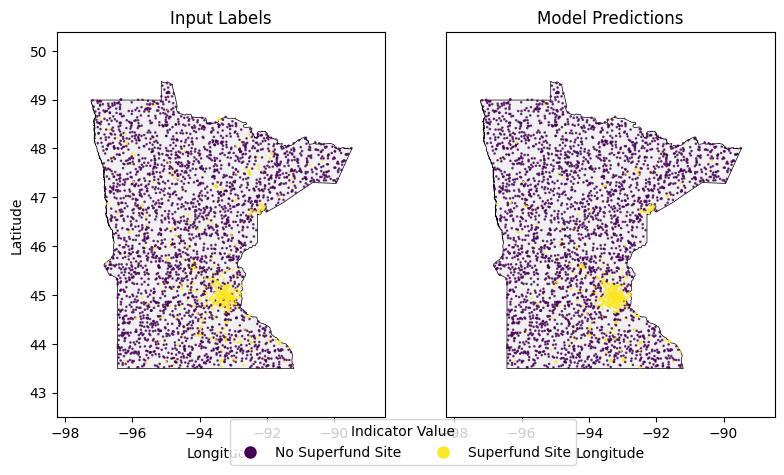

<Figure size 640x480 with 0 Axes>

In [ ]:
#PLOT ON STATE MAP
#------USER INPUT--------#
#THIS BLOCK OF CODE IS FOR STATE MAP ONLY. SEE BLOCK ABOVE FOR FULL US (FEDERAL) MAP.
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
import warnings
import requests # Import the requests library


# --- 1. LOAD THE STATE BORDER SHAPEFILE ---
state_zip_url = "https://www2.census.gov/geo/tiger/TIGER2025/STATE/tl_2025_us_state.zip"
local_zip_path = "us_states_2025.zip"

state_gdf = None # Initialize state_gdf to None

try:
  headers = {
  'User-Agent': 'Mozilla/5.0'
  }

  response = requests.get(state_zip_url, headers=headers)
  response.raise_for_status()

  with open(local_zip_path, 'wb') as f:
    f.write(response.content)

  # 2. Read the national zip file
  all_states_gdf = gpd.read_file(f"zip://{local_zip_path}")

  # 3. FILTER for your target state
  #------USER INPUT--------#
  #Change name of state as needed
  target_state = 'Minnesota' #change name here
  state_gdf = all_states_gdf[all_states_gdf['NAME'] == target_state].copy()

    # 4. Standardize CRS to EPSG:4326
  if state_gdf.crs != "EPSG:4326":
    state_gdf = state_gdf.to_crs("EPSG:4326")


  # Removed incorrect print statements referring to usa_gdf
  # print(f"Final CRS: {usa_gdf.crs}")
  # print(usa_gdf[['NAME', 'STUSPS', 'geometry']].head())

except Exception as e:
  print(f"An error occurred: {e}")


# --- 2. CONSTRUCT GDF_TEST FROM TEST DATA ---
# Combine c_test (coordinates), y_test (actual labels), and y_pred (predictions) into a single DataFrame
# y_test is a Series, so convert it to DataFrame and reset index to join with c_test
# y_pred is a numpy array, convert it to Series or DataFrame
# This is different from Maddy's code - GEE's production of gdf_test is not a GeoDataFrame.
# We need to convert gdf_test to a GeoDataFrame because accessing its CRS.

if 'c_test' in locals() and 'y_test' in locals() and 'y_pred' in locals():
    # Reset index of y_test to align with c_test if they don't share the same index after train_test_split
    temp_df = c_test.reset_index(drop=True)
    temp_df['actual_label'] = y_test.reset_index(drop=True)
    temp_df['prediction'] = y_pred

    # Convert to GeoDataFrame
    gdf_test = gpd.GeoDataFrame(
        temp_df,
        geometry=gpd.points_from_xy(temp_df['lon'], temp_df['lat']),
        crs="EPSG:4326"
    )
else:
    print("Error: 'c_test', 'y_test', or 'y_pred' are not defined.")
    gdf_test = None # Set gdf_test to None to prevent further errors

# Confirm both maps use the same CRS
if gdf_test is not None and state_gdf is not None: # Added check for state_gdf
    if state_gdf.crs != gdf_test.crs:
        print("Aligning CRS of State border map...")
        state_gdf = state_gdf.to_crs(gdf_test.crs)

    # --- 3. SET UP THE PLOT ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    plt.subplots_adjust(wspace=0.01)

    # --- 4. PREPARE YOUR BINARY COLORMAP ---
    # Assumes actual_label and prediction are binary (0 or 1)
    cmap_binary = plt.cm.get_cmap("viridis", 2) ## Get 2 discrete colors from viridis
    #this line is giving me a warning saying the command is getting discontinued, but I can't get its suggestions to work?

    # When plotting points with 'column' and a discrete cmap, ensure vmin/vmax are set for consistency
    vmin, vmax = 0, 1 # Assuming binary values are 0 and 1

    # --- 5. PLOT THE FIRST MAP
    state_gdf.plot(
        ax=axes[0],
        color='#f0f0f0',
        edgecolor='black',
        linewidth=0.5
    )
    # Plot your points on top
    plot1 = gdf_test.plot(
        column="actual_label",
        ax=axes[0],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap_binary,
        legend=False,
        markersize=0.75,
        alpha=0.75,
    )
    axes[0].set_title("Input Labels")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    # --- 6. PLOT THE SECOND MAP (Model Predictions) ---
    state_gdf.plot(
        ax=axes[1],
        color='#f0f0f0',
        edgecolor='black',
        linewidth=0.5
    )
    plot2 = gdf_test.plot(
        column="prediction",
        ax=axes[1],
        vmin=vmin,
        vmax=vmax,
        cmap=cmap_binary,
        legend=False,
        markersize=0.75,
        alpha=0.75,
    )
    axes[1].set_title("Model Predictions")
    axes[1].set_xlabel("Longitude")
    axes[1].yaxis.set_visible(False)

    # --- 7. SET THE MAP BOUNDARIES ---
    minx, miny, maxx, maxy = state_gdf.total_bounds
    axes[0].set_xlim(minx - 1, maxx + 1)
    axes[0].set_ylim(miny - 1, maxy + 1)
    axes[1].set_xlim(minx - 1, maxx + 1)
    axes[1].set_ylim(miny - 1, maxy + 1)

    # --- 8. ADD A BINARY LEGEND ---
    # Define custom handles for the binary legend
    legend_handles = [
        plt.Line2D([0], [0], marker='o', color='w', label='No Superfund Site',
                   markerfacecolor=cmap_binary(0), markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Superfund Site',
                   markerfacecolor=cmap_binary(1), markersize=10)
    ]

    # Add the legend to the figure
    # Adjust bbox_to_anchor and loc to place the legend appropriately outside the subplots
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, 0.0),
               title="Indicator Value")

    plt.show()

#save plot to drive
output_plot_filename = f'{today_date}_Map_.01_Statelabels_firsttest_no_train_test_split.pdf' #rename as needed
full_plot_path = os.path.join(output_folder, output_plot_filename)
plt.savefig(full_plot_path, dpi=300, bbox_inches='tight')